# Depth-only compact LLM ablation

This notebook compares the depth-only compact LLM policy with fixed depths 5, 10, 15, 20, and 30 at dimensions 25, 50, and 100. Every policy uses 100 trees, split size 2, leaf size 1, feature ratio 5/6, PCA 4, ten deterministic instances, benchmark seed 40, and five SMAC seeds. Lower values and gaps are better.

In [1]:
from pathlib import Path
import json, math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
plt.style.use('seaborn-v0_8-whitegrid')
HERE=Path.cwd()
if HERE.name!='40_03_depth': HERE=Path('experiments/synthaticBench/o1_deterministic/depth_policies/40_03_depth').resolve()
ROOT=HERE/'results'; DIMENSIONS=(25,50,100); SEEDS=tuple(range(5)); DEPTHS=(5,10,15,20,30); N=1000
POLICIES=['Depth-only LLM']+[f'Fixed depth {d}' for d in DEPTHS]

## Coverage

This table prevents incomplete array tasks from being silently mixed into the comparison.

In [2]:
def run_path(d,p,s):
    name='openai_compact_depth_only_policy' if p=='Depth-only LLM' else 'fixed_depth_'+p.rsplit(' ',1)[-1]
    return ROOT/f'dimension_{d}'/'benchmark_seed_40'/name/str(s)/'trajectory.json'
runs=[]
for d in DIMENSIONS:
 for p in POLICIES:
  for s in SEEDS:
   path=run_path(d,p,s)
   if not path.exists(): continue
   x=json.loads(path.read_text()); best=np.asarray(x['best_so_far']); f=float(x['f_min'])
   runs.append(dict(dimension=d,policy=p,seed=s,iteration=np.asarray(x['iteration']),best=best,
                    relative_gap=(best-f)/abs(f),final=best[-1],final_relative_gap=(best[-1]-f)/abs(f),payload=x,path=path))
coverage=pd.DataFrame([dict(dimension=r['dimension'],policy=r['policy'],seed=r['seed'],trials=len(r['best'])) for r in runs])
expected=pd.MultiIndex.from_product([DIMENSIONS,POLICIES],names=['dimension','policy']).to_frame(index=False)
summary=coverage.groupby(['dimension','policy']).agg(runs=('seed','nunique'),min_trials=('trials','min'),max_trials=('trials','max')).reset_index() if len(coverage) else pd.DataFrame()
display(expected.merge(summary,how='left').fillna(0))

,dimension,policy,runs,min_trials,max_trials
0,25,Depth-only LLM,5,1000,1000
1,25,Fixed depth 5,5,1000,1000
2,25,Fixed depth 10,5,1000,1000
3,25,Fixed depth 15,5,1000,1000
4,25,Fixed depth 20,5,1000,1000
5,25,Fixed depth 30,5,1000,1000
6,50,Depth-only LLM,5,1000,1000
7,50,Fixed depth 5,5,1000,1000
8,50,Fixed depth 10,5,1000,1000
9,50,Fixed depth 15,5,1000,1000


## LLM trajectories by dimension

Each line is one SMAC seed. Dotted lines mark depth decisions at trials 100, 250, and 500.

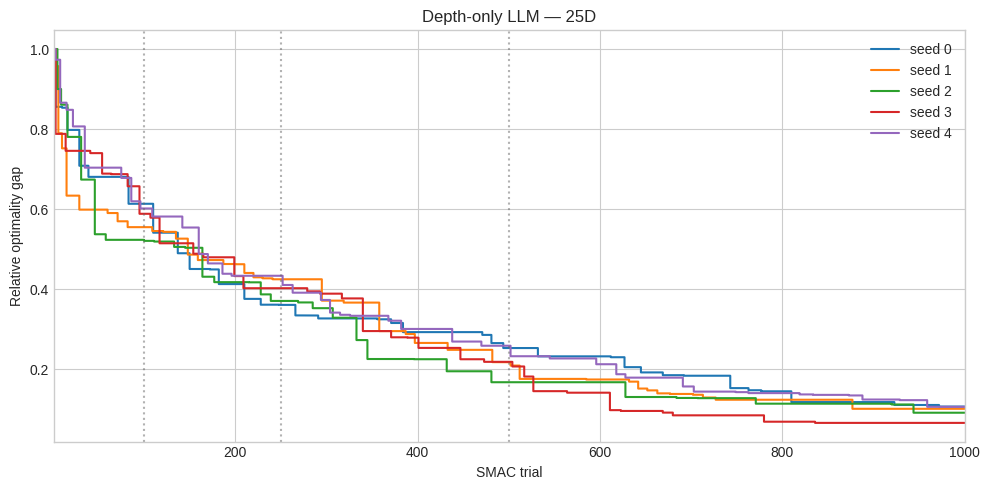

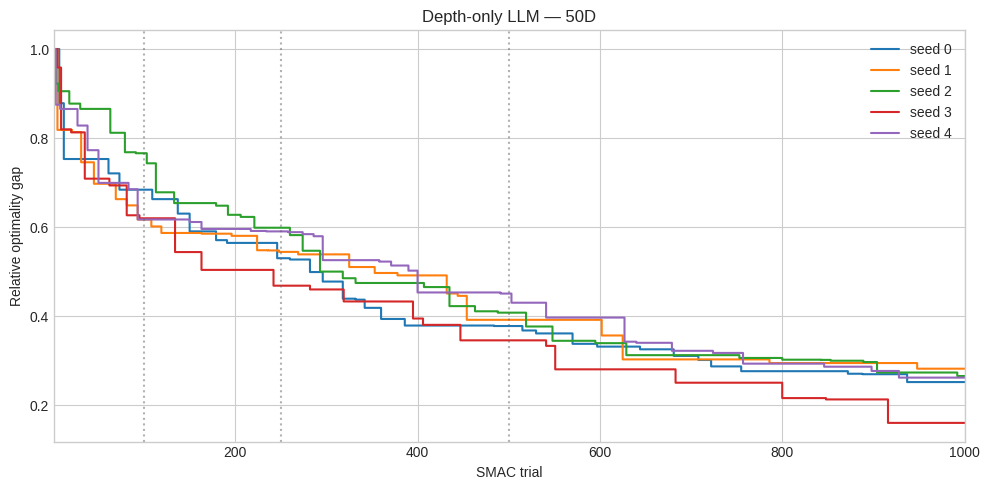

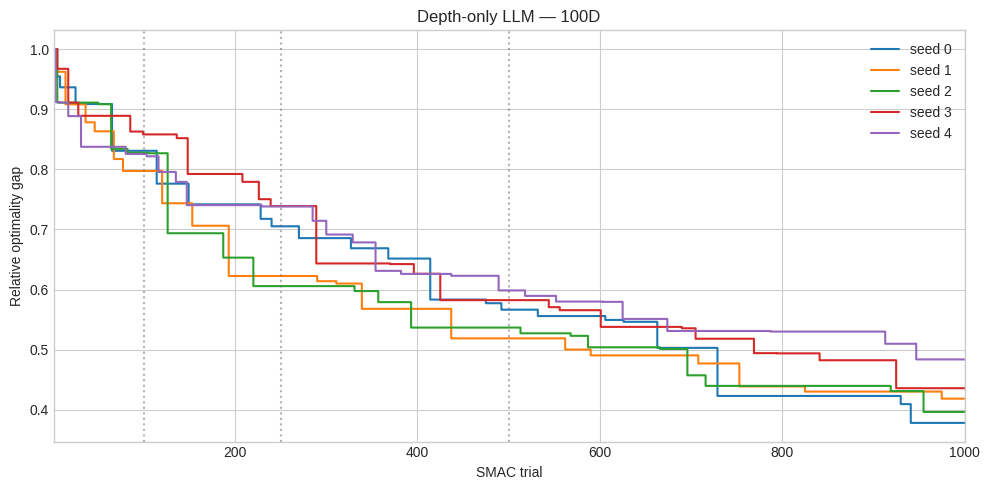

In [3]:
for d in DIMENSIONS:
 fig,ax=plt.subplots(figsize=(10,5))
 for r in runs:
  if r['dimension']==d and r['policy']=='Depth-only LLM': ax.step(r['iteration'],r['relative_gap'],where='post',label=f"seed {r['seed']}")
 for cp in (100,250,500): ax.axvline(cp,color='.4',ls=':',alpha=.5)
 ax.set(title=f'Depth-only LLM — {d}D',xlabel='SMAC trial',ylabel='Relative optimality gap',xlim=(1,N)); ax.legend(); plt.tight_layout(); plt.show()

## Mean trajectories and 95% confidence intervals

Lines are arithmetic means across the five matched SMAC seeds. Shading is a two-sided Student-t 95% confidence interval for the mean, not the spread of individual runs.

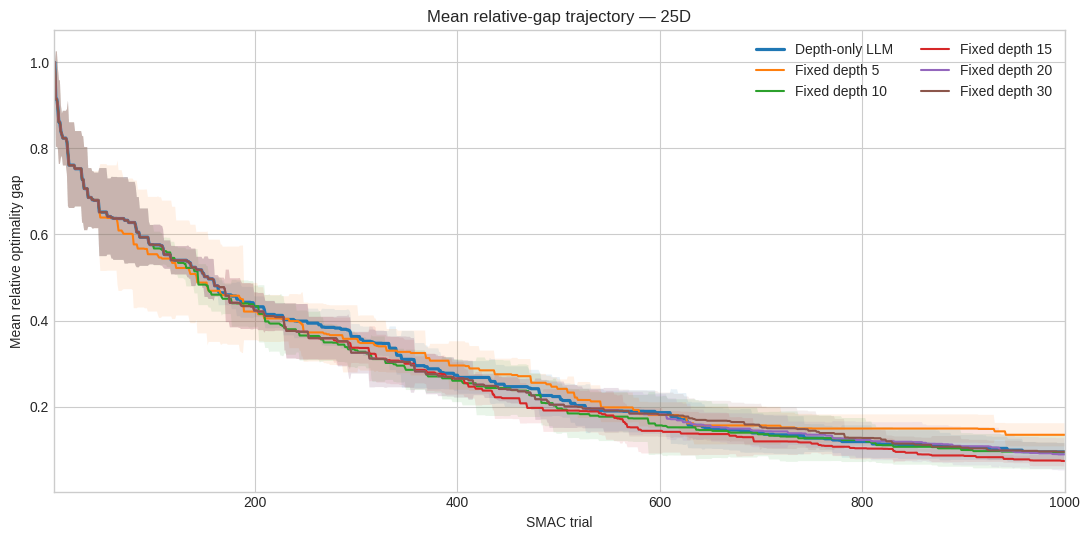

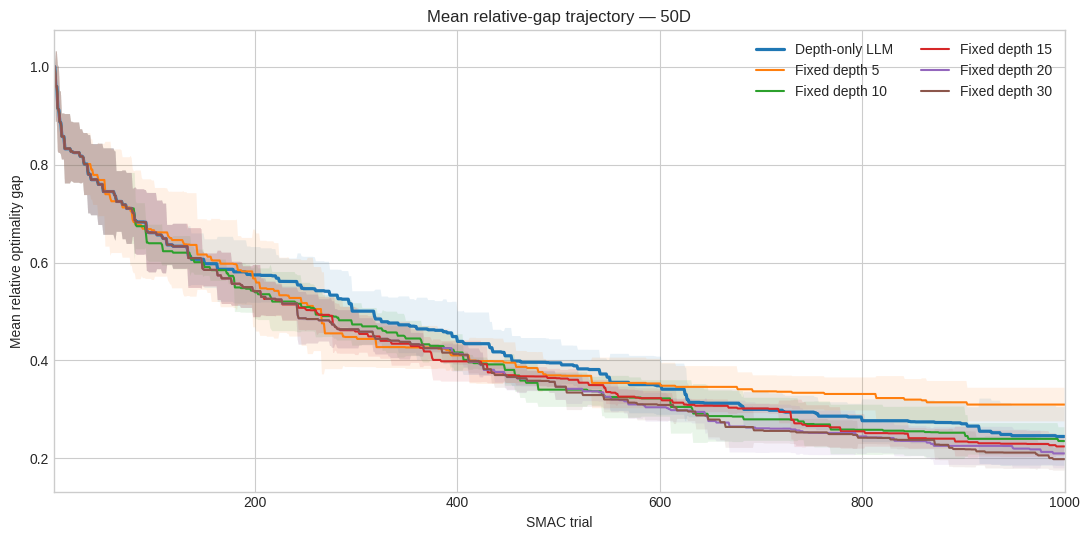

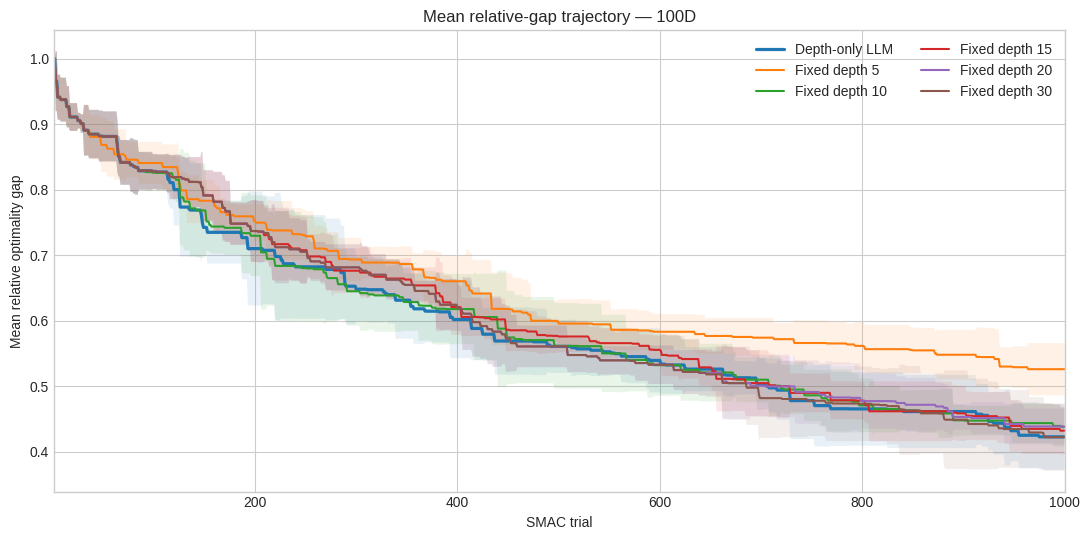

In [4]:
T95={2:12.706,3:4.303,4:3.182,5:2.776}
def ci(curves):
 a=np.vstack(curves); m=a.mean(0); h=T95[len(a)]*a.std(0,ddof=1)/math.sqrt(len(a)) if len(a)>1 else np.zeros_like(m); return m,m-h,m+h
for d in DIMENSIONS:
 fig,ax=plt.subplots(figsize=(11,5.5))
 for p in POLICIES:
  q=sorted([r for r in runs if r['dimension']==d and r['policy']==p and len(r['best'])==N],key=lambda r:r['seed'])
  if not q: continue
  m,lo,hi=ci([r['relative_gap'] for r in q]); x=np.arange(1,N+1); ax.plot(x,m,label=p,lw=2.3 if p=='Depth-only LLM' else 1.5); ax.fill_between(x,lo,hi,alpha=.1)
 ax.set(title=f'Mean relative-gap trajectory — {d}D',xlabel='SMAC trial',ylabel='Mean relative optimality gap',xlim=(1,N)); ax.legend(ncol=2); plt.tight_layout(); plt.show()

## Final performance

Every point is one seed's final incumbent. The ranking table compares mean final gap and whole-run normalized area under the gap curve.

/tmp/io632776/login23-4_485133/ipykernel_492631/571175198.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  fig,ax=plt.subplots(figsize=(11,5)); ax.boxplot(values,labels=POLICIES,showfliers=False)


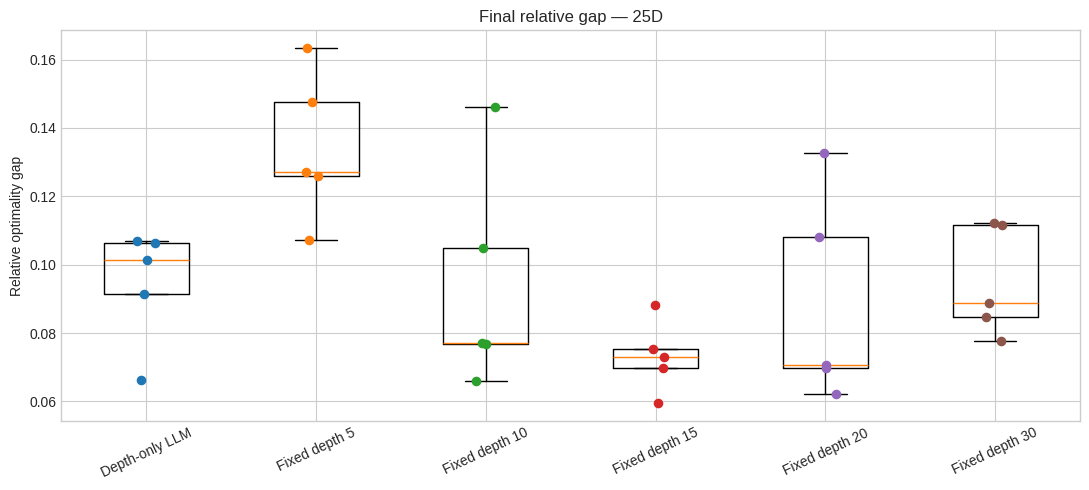

/tmp/io632776/login23-4_485133/ipykernel_492631/571175198.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  fig,ax=plt.subplots(figsize=(11,5)); ax.boxplot(values,labels=POLICIES,showfliers=False)


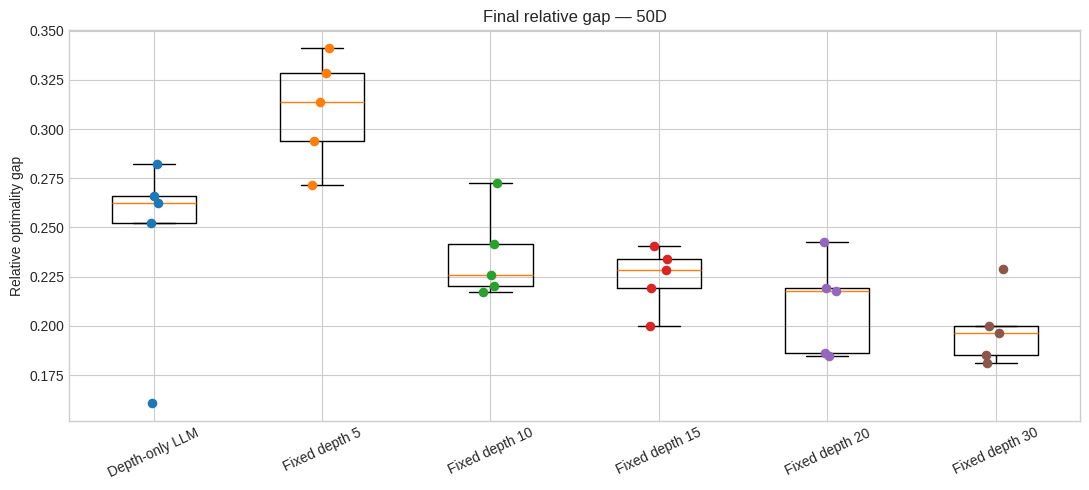

/tmp/io632776/login23-4_485133/ipykernel_492631/571175198.py:5: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  fig,ax=plt.subplots(figsize=(11,5)); ax.boxplot(values,labels=POLICIES,showfliers=False)


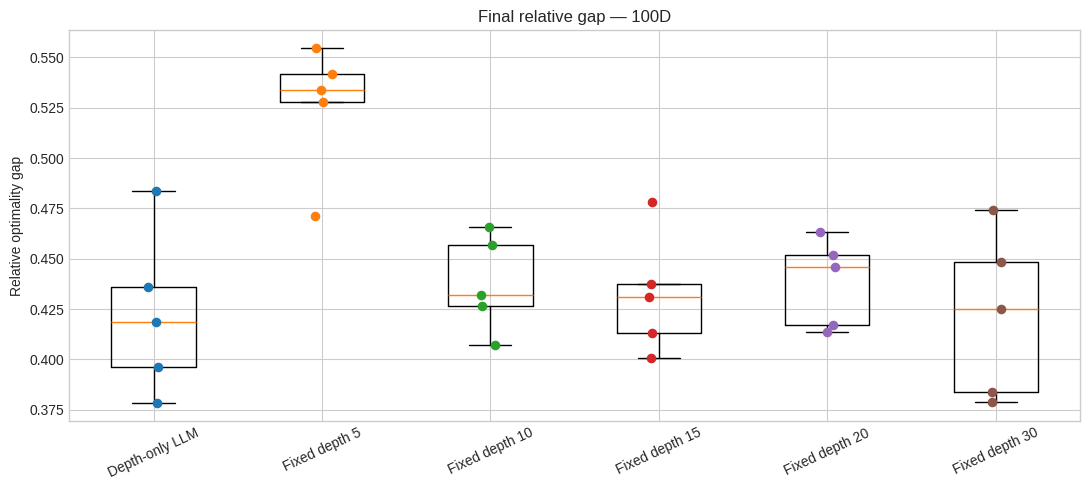

,dimension,policy,runs,mean_gap,sd_gap,median_gap,mean_normalized_auc
2,25,Fixed depth 15,5,0.073174,0.010318,0.073047,0.267248
3,25,Fixed depth 20,5,0.088723,0.030387,0.070715,0.279171
1,25,Fixed depth 10,5,0.094111,0.032358,0.077150,0.272916
0,25,Depth-only LLM,5,0.094426,0.016973,0.101321,0.283959
4,25,Fixed depth 30,5,0.095004,0.015943,0.088927,0.280991
5,25,Fixed depth 5,5,0.134300,0.021632,0.127203,0.295245
10,50,Fixed depth 30,5,0.198322,0.018799,0.196463,0.397106
9,50,Fixed depth 20,5,0.210116,0.024578,0.217551,0.398627
8,50,Fixed depth 15,5,0.224365,0.015809,0.228366,0.406436
7,50,Fixed depth 10,5,0.235315,0.022742,0.225666,0.407328


In [5]:
finals=pd.DataFrame([dict(dimension=r['dimension'],policy=r['policy'],seed=r['seed'],final=r['final'],relative_gap=r['final_relative_gap'],normalized_auc=r['relative_gap'].mean()) for r in runs if len(r['best'])==N])
for d in DIMENSIONS:
 part=finals[finals.dimension==d]; values=[part.loc[part.policy==p,'relative_gap'].values for p in POLICIES]
 if not all(len(v) for v in values): continue
 fig,ax=plt.subplots(figsize=(11,5)); ax.boxplot(values,labels=POLICIES,showfliers=False)
 rng=np.random.default_rng(40+d)
 for i,v in enumerate(values,1): ax.scatter(i+rng.uniform(-.06,.06,len(v)),v,s=35,zorder=3)
 ax.set(title=f'Final relative gap — {d}D',ylabel='Relative optimality gap'); ax.tick_params(axis='x',rotation=25); plt.tight_layout(); plt.show()
display(finals.groupby(['dimension','policy']).agg(runs=('seed','count'),mean_gap=('relative_gap','mean'),sd_gap=('relative_gap','std'),median_gap=('relative_gap','median'),mean_normalized_auc=('normalized_auc','mean')).reset_index().sort_values(['dimension','mean_gap']))

## Selected depths

The table shows the only hyperparameter returned by the LLM at each checkpoint. The audit assertion verifies that all persisted transitions retained the immutable RF settings.

In [6]:
rows=[]
for r in runs:
 if r['policy']!='Depth-only LLM': continue
 audit=r['payload'].get('llm_policy',{})
 for cp,v in audit.get('decisions',{}).items():
  st=v['settings']; assert st['n_trees']==100 and st['min_samples_split']==2 and st['min_samples_leaf']==1 and np.isclose(st['feature_ratio'],5/6)
  usage=v.get('usage') or {}
  rows.append(dict(dimension=r['dimension'],seed=r['seed'],checkpoint=int(cp),max_depth=st['max_depth'],confidence=v['confidence'],input_tokens=usage.get('input_tokens'),output_tokens=usage.get('output_tokens'),reason=v['reason']))
decisions=pd.DataFrame(rows)
display(decisions.sort_values(['dimension','seed','checkpoint']) if len(decisions) else decisions)
if len(decisions): display(decisions.groupby(['dimension','checkpoint']).max_depth.agg(['mean','std','min','max']))

,dimension,seed,checkpoint,max_depth,confidence,input_tokens,output_tokens,reason
0,25,0,100,12,0.68,4889,225,Recent unconstrained trees average depth 8.43 ...
1,25,0,250,14,0.67,4965,213,Depth 12 is now strongly saturated (recent uti...
2,25,0,500,16,0.62,5016,176,Recent forests are essentially saturated at de...
3,25,1,100,12,0.72,4874,258,Current depth 20 is substantially underutilize...
4,25,1,250,16,0.70,4954,322,Depth 12 is increasingly binding (recent utili...
5,25,1,500,20,0.68,5009,200,Recent trees nearly saturate depth 16 (mean ut...
6,25,2,100,12,0.68,4885,361,Recent trees average depth 8.19 under a limit ...
7,25,2,250,16,0.72,4970,223,Depth 12 is effectively saturated in the lates...
8,25,2,500,18,0.67,5028,175,Current depth-16 trees are increasingly near t...
9,25,3,100,12,0.67,4903,214,Recent trees average depth 7.48 under limit 20...


mean       std  min  max
dimension checkpoint                          
25        100         12.0  0.000000   12   12
          250         14.8  1.095445   14   16
          500         17.2  1.788854   16   20
50        100         12.0  4.690416    8   20
          250         14.4  3.286335   12   20
          500         17.2  3.898718   14   24
100       100         10.0  2.000000    8   12
          250         14.0  2.000000   12   16
          500         17.2  1.095445   16   18